In [1]:
#user = r"\SagixOffice"  # HomeOffice
user = r"\vie43sq"  # University
import sys
sys.path.append(rf"C:\Users{user}\OneDrive - Universität Würzburg\GitHub\Photoswitching")

import src.transitions as tr
import src.miscellaneous as mi
import src.fluorophores as fl
import src.statistics as st
import src.simulation as si
import src.emissions as em
import src.blinking as bl
import src.tcspc as tc
import src.fcs as fc

import numpy as np

%load_ext autoreload
%autoreload 2

C:\Users\vie43sq\Miniconda3\envs\MarkovModels\lib\site-packages\pycorrelate\pycorrelate.py:118: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  def ucorrelate(t, u, maxlag=None):


In [2]:
fluorophores = fl.construct_fluorophores('cy5', 3, 4)
fluorophore_system = fl.FluorophoreSystem(fluorophores=fluorophores)

In [3]:
transitions = tr.load_transitions(fluorophore_system, 2.5, 640)
transition_set = tr.TransitionSet(transitions, fluorophore_system)
transition_set = transition_set.filter_by_abbreviation(remove_list=['HFRET', 'CFRET', 'TFRET'])
transition_set.finalize()

In [4]:
simulation = si.Simulation(transition_set)
simulation.run(size=int(1e7), end_time=10, seed=3, use_memmap=r'D:\memmaps\3 nm\4 fluos')

In [9]:
emissions = em.Emissions(simulation, photon_collection_rate=0.01, resample='1s', emccd_gain=100, seed=100)
emissions.save(path='', name_extension='_3nm_4fluos')

In [11]:
blinking = bl.Blinking(emissions)

array([[<AxesSubplot:title={'center':'intensity distribution'}, xlabel='photon count', ylabel='PD'>]],
      dtype=object)

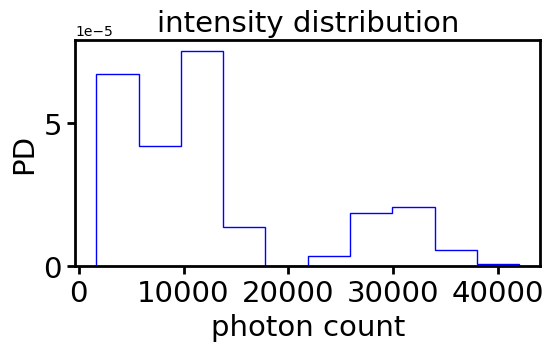

In [12]:
emissions.plot('histogram', histtype='step')

array([[<AxesSubplot:title={'center':'ON periods'}, xlabel='consecutive frames', ylabel='PD'>]],
      dtype=object)

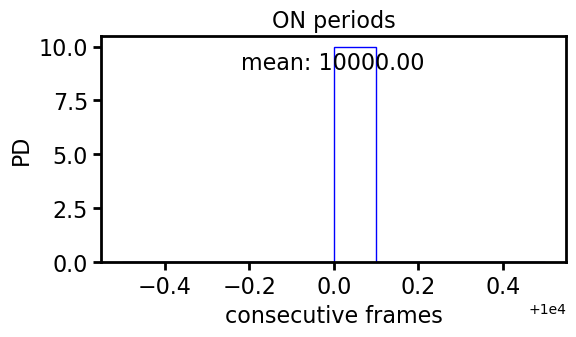

In [13]:
blinking.plot(mode='on_histogram', histtype='step')

C:\Users\vie43sq\Miniconda3\envs\MarkovModels\lib\site-packages\numpy\lib\histograms.py:906: RuntimeWarning: invalid value encountered in true_divide
  return n/db/n.sum(), bin_edges
C:\Users\vie43sq\Miniconda3\envs\MarkovModels\lib\site-packages\numpy\core\fromnumeric.py:3474: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\vie43sq\Miniconda3\envs\MarkovModels\lib\site-packages\numpy\core\_methods.py:189: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


array([[<AxesSubplot:title={'center':'OFF periods'}, xlabel='consecutive frames', ylabel='PD'>]],
      dtype=object)

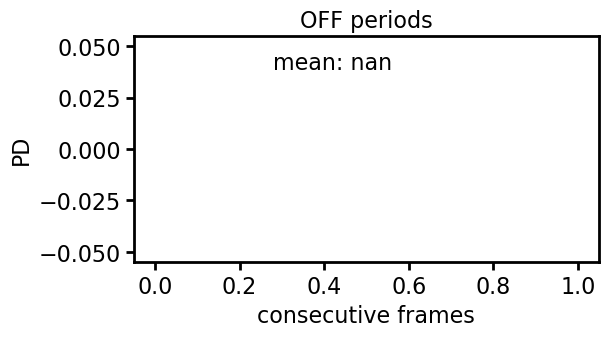

In [15]:
blinking.plot(mode='off_histogram', histtype='step')

array([[<AxesSubplot:title={'center':'fluorescence trajectory'}, xlabel='time [s]', ylabel='photon count'>]],
      dtype=object)

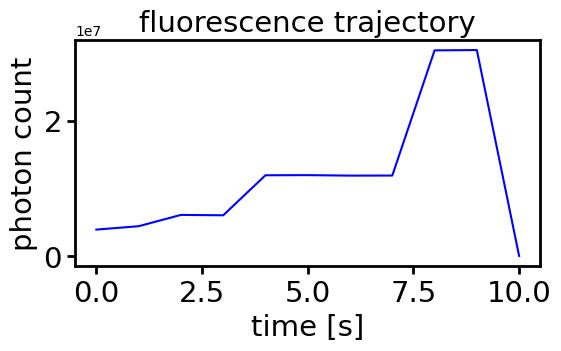

In [10]:
emissions.plot('time_series')